# Fade the release — grid search

`econ_release_fade_backtest.ipynb` reports one configuration and sweeps a knob at a time. This one
runs the **product**: every instrument against every window against every release set against every
move threshold, scored on Sharpe, hit rate and basis points per trade.

That is a dangerous thing to do and the notebook is organised around saying so. With a thousand
configurations, the best Sharpe is a number you would obtain from pure noise. Three things
therefore come **before** the leaderboard:

**§1 ties the fast pricer to the engine.** The grid cannot afford to run `QueryDrivenBacktest` a
thousand times, so it prices arithmetically off the same causal bars. A fast path that is never
checked against the slow one is a second implementation of the strategy rather than an optimisation
of the first, so it is checked here, on the real book, to floating point.

**§4 prices the search.** The Deflated Sharpe discounts the winner by how many configurations were
tried. It is the first column to read, not the last.

**§5 runs the whole grid on the wrong day.** The identical product of configurations, with every
release timestamp shifted onto a minute that had no release. Whatever the leaderboard finds, the
placebo grid finds the same shape if the effect is the clock rather than the release — and comparing
the two *distributions* is far more informative than comparing two single books.

The cost line is drawn on every chart at 0.5 bp, the measured SR3 tick. A configuration whose gross
edge sits below it is not a small opportunity; it is a negative one.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, copy, itertools, time, warnings
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-eco"
HERE = Path(REPO) / "notebooks" / "backtests" / "econ_release_fade"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large",
                       "axes.labelsize": "large"})
warnings.filterwarnings("ignore", category=FutureWarning)

import econ_fade_common as G
import econ_fade_config as C
from econ_fade_prewarm import load_events

RAW = load_events()
n_bars = G.load_bar_cache()
n_dv01 = G.load_dv01()
if n_bars == 0:
    raise RuntimeError("no warm bars -- run `python econ_fade_prewarm.py --stage all` first")

GRID_CSV = G.CACHE / "grid_results.csv"
PLACEBO_CSV = G.CACHE / "grid_results_placebo.csv"

print(f"release book {len(RAW):,} minutes   bars {n_bars:,} symbol-days   "
      f"DV01 {n_dv01} contracts")

C:\Users\chris\clee\ARBS-eco\notebooks\backtests\econ_release_fade\econ_fade_common.py:55: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  from rateslib.scheduling import next_imm


release book 2,870 minutes   bars 37,402 symbol-days   DV01 128 contracts


## 1. The fast pricer is the engine

Before a single grid cell is trusted, the closed form is checked against `QueryDrivenBacktest` on
the real book — the same queries, the same position handlers, the same unwinds. They must agree to
floating point, because the engine's realised dollars divided by the position's DV01 *is* the
closed form's basis points, exactly.

In [2]:
BASE = C.spec("base", events={"impacts": ["high", "medium"]})
book = G.build_book(BASE, RAW)
t0 = time.time()
V = G.validate_fast_vs_engine(book, tol=1e-6, show_progress=True)
print(f"engine run took {time.time()-t0:.1f}s for {V['trades_engine']} trades")

checks = [
    ("same trade count", V["trades_engine"] == V["trades_fast"],
     f"{V['trades_engine']} vs {V['trades_fast']}"),
    ("every trade matched by tag", V["matched"] == V["trades_engine"],
     f"{V['matched']}/{V['trades_engine']}"),
    ("P&L agrees to 1e-6 bp", V["n_over_tol"] == 0, f"max |diff| {V['max_abs_diff']:.3e} bp"),
]
display(pd.DataFrame([{"check": c, "result": "PASS" if ok else "FAIL", "value": v}
                      for c, ok, v in checks]).set_index("check"))
assert all(ok for _, ok, _ in checks), "the fast pricer does NOT reproduce the engine"

t0 = time.time()
_ = G.fast_backtest(book)
print(f"closed form took {time.time()-t0:.3f}s for the same book -- which is what makes")
print("a grid of a thousand configurations possible at all.")

base:   0%|          | 0/2164 [00:00<?, ?step/s]

base:   1%|          | 21/2164 [00:00<00:10, 208.23step/s]

base:   2%|▏         | 42/2164 [00:00<00:10, 193.84step/s]

base:   3%|▎         | 69/2164 [00:00<00:09, 224.43step/s]

base:   4%|▍         | 97/2164 [00:00<00:08, 245.55step/s]

...

base:  99%|█████████▉| 2141/2164 [00:09<00:00, 249.19step/s]

base: 100%|██████████| 2164/2164 [00:09<00:00, 237.77step/s]

engine run took 9.4s for 1082 trades


,result,value
check,,
same trade count,PASS,1082 vs 1082
every trade matched by tag,PASS,1082/1082
P&L agrees to 1e-6 bp,PASS,max |diff| 0.000e+00 bp


closed form took 0.015s for the same book -- which is what makes
a grid of a thousand configurations possible at all.


## 2. The grid

Five axes. Each is a genuine degree of freedom a desk would have to pick, and each multiplies the
number of ways to find a good-looking number by accident.

| axis | values | why it is a real choice |
|---|---|---|
| instrument | SR3 ranks 1–8, ZQ 1–4, ZT/ZF/ZN/ZB front | where on the curve the release lands |
| release set | tier 1, tier 1+2, 08:30 block, clustered, CPI, payrolls | which prints are worth trading |
| measurement | 1, 2, 5 minutes | how much of the burst the signal sees |
| holding | 15, 30, 60, 120, 240 minutes | how long the fade is given |
| move filter | ≥ 0, ≥ 1, ≥ 2 bp | whether small prints are worth the cost |

Entry is pinned to one minute **after** the measurement window closes throughout, so a longer look
is always paid for with a later entry and no cell fills at the price it read the signal from.
Every price in the grid is the close of a bar that had fully closed by the timestamp — Barchart
minute bars are start-stamped, so the release itself sits *inside* the bar labelled with the release
minute, and reading that bar's close as a pre-release price would measure the drift after the print
rather than the print.

In [3]:
#: The strip is thinned to every rank up to 4 plus 6 and 8 rather than all
#: eight, and the move filter to two values rather than three. Both are stated
#: rather than silently applied: at ~0.35s a configuration the full product is
#: several hours across three grids, and a grid that gets quietly run at a
#: smaller size than its prose claims is worse than a smaller grid.
INSTRUMENTS = (
    [("SR3 r%d" % n, {"family": "stir", "root": "USD_STIR", "rank": n}) for n in (1, 2, 3, 4, 6, 8)] +
    [("ZQ r%d" % n, {"family": "stir", "root": "ZQ", "rank": n}) for n in (1, 2)] +
    [(k, {"family": "ust", "root": k, "rank": 1}) for k in ("TU", "FV", "TY", "US")]
)
RELEASE_SETS = [
    ("tier1", {"impacts": ["high"]}),
    ("tier1+2", {"impacts": ["high", "medium"]}),
    ("0830", {"impacts": ["high", "medium"], "release_times_ny": ["08:30"]}),
    ("clustered", {"impacts": ["high", "medium"], "min_events_in_minute": 2}),
    ("CPI", {"impacts": ["high", "medium"], "titles_include": [r"\bCPI\b"]}),
    ("payrolls", {"impacts": ["high", "medium"],
                  "titles_include": [r"^Non-Farm Employment Change$", r"^Unemployment Rate$"]}),
]
MEASURE = [1, 2, 5]
HOLD = [15, 30, 60, 120, 240]
MOVE = [0.0, 2.0]

def build_grid(direction="fade"):
    out = []
    for (inm, ispec), (rnm, rspec), m, h, mv in itertools.product(
            INSTRUMENTS, RELEASE_SETS, MEASURE, HOLD, MOVE):
        if h <= m + 1:
            continue
        out.append(C.spec(
            f"{inm}|{rnm}|m{m}|h{h}|mv{mv:g}",
            instrument=ispec, events=rspec,
            # Entry is always one minute AFTER the measurement closes: filling at
            # the price the signal was read from is a zero-latency assumption.
            timing={"measure_end_min": m, "entry_offset_min": m + 1, "exit_offset_min": h},
            signal={"direction": direction, "min_move_bp": mv},
        ))
    return out

GRID = build_grid()
print(f"{len(GRID):,} configurations")
print(f"  {len(INSTRUMENTS)} instruments x {len(RELEASE_SETS)} release sets x "
      f"{len(MEASURE)} measurement x {len(HOLD)} holding x {len(MOVE)} move filters")
print(f"  dropped: SR3 ranks 5 and 7, ZQ ranks 3-4, the 1bp move filter, and every")
print(f"  (measure, hold) pair with hold <= measure + 1 -- see the note above the axes")

2,160 configurations
  12 instruments x 6 release sets x 3 measurement x 5 holding x 2 move filters
  dropped: SR3 ranks 5 and 7, ZQ ranks 3-4, the 1bp move filter, and every
  (measure, hold) pair with hold <= measure + 1 -- see the note above the axes


In [4]:
def run_grid(cfgs, raw, label, csv_path, *, resume=True):
    '''Run every config through the closed form, checkpointing as it goes.

    Resumable by NAME. A grid that has to start over because the kernel died at
    config 900 is a grid that quietly gets run at a smaller size instead.
    '''
    done = {}
    if resume and Path(csv_path).exists():
        prev = pd.read_csv(csv_path)
        done = {r["config"]: r for _, r in prev.iterrows()}
        print(f"resuming {label}: {len(done)} of {len(cfgs)} already scored")

    rows, closed_by = [], {}
    todo = [c for c in cfgs if c["name"] not in done]
    try:
        from tqdm.auto import tqdm
        it = tqdm(todo, desc=label)
    except Exception:
        it = todo

    t0 = time.time()
    n_err, errs = 0, {}
    for cfg in it:
        nm = cfg["name"]
        try:
            r = C.run_config(cfg, raw, engine=False)
        except Exception as ex:
            # Recorded and counted, never swallowed -- a grid that quietly lost
            # an instrument reports a smaller search than it actually ran.
            n_err += 1
            errs.setdefault(f"{type(ex).__name__}: {str(ex)[:90]}", 0)
            errs[f"{type(ex).__name__}: {str(ex)[:90]}"] += 1
            continue
        s = r.stats
        inm, rnm, mm, hh, mv = nm.split("|")
        rows.append({
            "config": nm, "instrument": inm, "release_set": rnm,
            "measure_min": int(mm[1:]), "hold_min": int(hh[1:]), "min_move_bp": float(mv[2:]),
            "trades": s.get("trades", 0), "total_bp": s.get("total_bp", np.nan),
            "avg_bp": s.get("avg_bp", np.nan), "hit_rate": s.get("hit_rate", np.nan),
            "sharpe": s.get("sharpe", np.nan), "sr_per_trade": s.get("sr_per_trade", np.nan),
            "t_stat": s.get("t_stat", np.nan), "max_dd_bp": s.get("max_dd_bp", np.nan),
            "trades_per_year": s.get("trades_per_year", np.nan),
            "span_days": s.get("span_days", np.nan),
        })
        if not r.closed.empty:
            closed_by[nm] = r.closed.pnl_bp.to_numpy(float)

    new = pd.DataFrame(rows)
    out = pd.concat([pd.DataFrame(list(done.values())), new], ignore_index=True) if done else new
    out.to_csv(csv_path, index=False)
    print(f"{label}: {len(out):,} configs in {time.time()-t0:.0f}s -> {csv_path}")
    if n_err:
        print(f"  {n_err:,} of {len(todo):,} could not be priced and are ABSENT from the table:")
        for msg, k in sorted(errs.items(), key=lambda x: -x[1]):
            print(f"    {k:>5}x  {msg}")
    return out, closed_by

RESULTS, PNL = run_grid(GRID, RAW, "grid", GRID_CSV)
display(RESULTS.describe().round(4))

grid:   0%|          | 0/2160 [00:00<?, ?it/s]

grid: 2,160 configs in 757s -> C:\Users\chris\clee\ARBS-eco\notebooks\backtests\econ_release_fade\_cache\grid_results.csv


,measure_min,hold_min,min_move_bp,trades,total_bp,avg_bp,hit_rate,sharpe,sr_per_trade,t_stat,max_dd_bp,trades_per_year,span_days
count,2160.0000,2160.000,2160.0000,2160.0000,2097.0000,2097.0000,2097.0000,2.055000e+03,2.097000e+03,2.097000e+03,2097.0000,2097.0000,2097.0000
mean,2.6667,93.000,1.0000,318.3644,-35.5860,-0.1629,0.4135,-2.717470e+08,-2.372829e+08,-3.355686e+08,-70.0873,51.8366,2422.5383
std,1.7001,81.848,1.0002,360.5085,56.6821,0.2675,0.1073,1.231886e+10,1.086590e+10,1.536670e+10,63.2895,64.5205,779.6494
min,1.0000,15.000,0.0000,0.0000,-299.0000,-1.4811,0.0000,-5.584400e+11,-4.975822e+11,-7.036874e+11,-337.6484,1.2596,0.0000
25%,1.0000,30.000,0.0000,53.0000,-56.9391,-0.2835,0.4000,-4.742000e-01,-8.600000e-02,-1.169600e+00,-102.0000,9.7507,2618.0000
50%,2.0000,60.000,1.0000,182.5000,-16.5000,-0.1115,0.4408,-2.450000e-01,-3.880000e-02,-6.186000e-01,-53.0097,30.5697,2771.9583
75%,5.0000,120.000,2.0000,570.0000,-0.5000,-0.0068,0.4669,-2.010000e-02,-7.000000e-04,-1.290000e-02,-21.7516,80.6408,2771.9583
max,5.0000,240.000,2.0000,1757.0000,82.0000,0.7985,1.0000,1.811400e+00,5.000000e-01,2.408900e+00,0.0000,365.2500,2772.9688


## 3. The leaderboard, with the trade count read first

A configuration with eleven trades and a Sharpe of 3 is not a discovery. The table is filtered to
configurations with enough trades to be an estimate at all, and the gross edge is shown next to the
tick it has to clear.

1,670 of 2,160 configurations have >= 50 trades


,instrument,release_set,measure_min,hold_min,min_move_bp,trades,span_days,avg_bp,hit_rate,sr_per_trade,sharpe,t_stat
config,,,,,,,,,,,,
SR3 r1|CPI|m5|h15|mv0,SR3 r1,CPI,5,15,0.0,67,2740.9583,0.2052,0.4925,0.2307,0.6893,1.8881
ZQ r2|tier1+2|m5|h15|mv0,ZQ r2,tier1+2,5,15,0.0,114,646.0104,0.1009,0.3158,0.2256,1.8114,2.4089
SR3 r2|payrolls|m5|h15|mv2,SR3 r2,payrolls,5,15,2.0,50,2771.9583,0.2800,0.5400,0.1831,0.4700,1.2948
SR3 r8|payrolls|m5|h15|mv2,SR3 r8,payrolls,5,15,2.0,54,2771.9583,0.4259,0.5000,0.1797,0.4794,1.3206
SR3 r8|payrolls|m1|h30|mv2,SR3 r8,payrolls,1,30,2.0,62,2771.9583,0.6290,0.5000,0.1693,0.4838,1.3328
ZQ r2|tier1|m5|h15|mv0,ZQ r2,tier1,5,15,0.0,87,646.0104,0.0690,0.3103,0.1675,1.1745,1.5620
SR3 r8|payrolls|m5|h60|mv2,SR3 r8,payrolls,5,60,2.0,54,2771.9583,0.6944,0.5556,0.1594,0.4251,1.1712
SR3 r8|payrolls|m1|h60|mv2,SR3 r8,payrolls,1,60,2.0,62,2771.9583,0.7258,0.5484,0.1585,0.4530,1.2479
SR3 r8|payrolls|m5|h30|mv2,SR3 r8,payrolls,5,30,2.0,54,2771.9583,0.4722,0.4815,0.1468,0.3917,1.0790


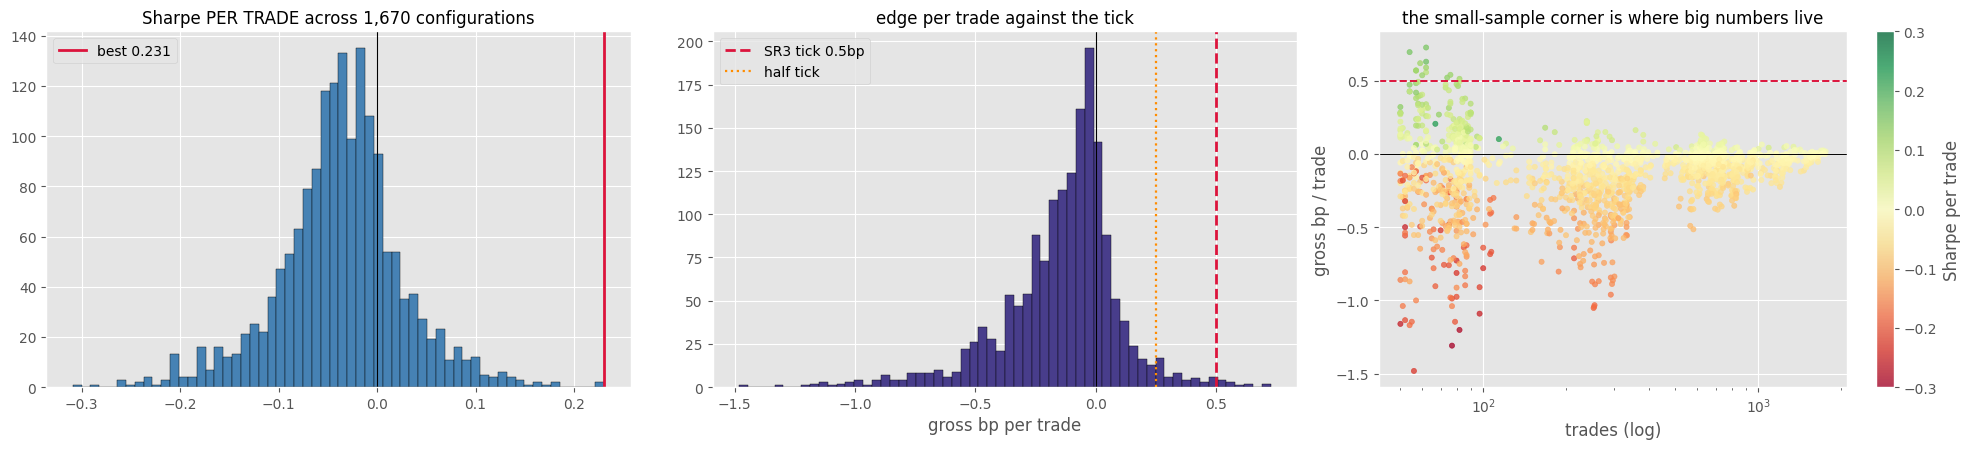


configurations whose GROSS edge clears one SR3 tick (0.5bp): 12 of 1670
configurations with a positive gross edge at all: 378


In [5]:
MIN_TRADES = 50
elig = RESULTS[RESULTS.trades >= MIN_TRADES].copy()
elig["gross_vs_tick"] = elig.avg_bp - 0.5
print(f"{len(elig):,} of {len(RESULTS):,} configurations have >= {MIN_TRADES} trades")

# Ranked on sr_per_trade, NOT the annualised Sharpe. The deflated Sharpe,
# Romano-Wolf and RAS all consume the per-trade figure, so ranking on the
# annualised one would select a winner the tests below never scored -- and the
# annualised column is withheld entirely for books spanning under 30 days,
# which cannot support it.
top = elig.sort_values("sr_per_trade", ascending=False).head(25)
display(top[["config", "instrument", "release_set", "measure_min", "hold_min", "min_move_bp",
             "trades", "span_days", "avg_bp", "hit_rate", "sr_per_trade", "sharpe", "t_stat"]]
        .set_index("config").round(4))

fig, axes = plt.subplots(1, 3, figsize=(20, 4.6))
axes[0].hist(elig.sr_per_trade, bins=60, color="steelblue", edgecolor="k", lw=.3)
axes[0].axvline(0, color="k", lw=.8)
axes[0].axvline(elig.sr_per_trade.max(), color="crimson", lw=2,
                label=f"best {elig.sr_per_trade.max():.3f}")
axes[0].set_title(f"Sharpe PER TRADE across {len(elig):,} configurations"); axes[0].legend()

axes[1].hist(elig.avg_bp, bins=60, color="darkslateblue", edgecolor="k", lw=.3)
axes[1].axvline(0, color="k", lw=.8)
axes[1].axvline(0.5, color="crimson", lw=2, ls="--", label="SR3 tick 0.5bp")
axes[1].axvline(0.25, color="darkorange", lw=1.6, ls=":", label="half tick")
axes[1].set_xlabel("gross bp per trade"); axes[1].legend()
axes[1].set_title("edge per trade against the tick")

sc = axes[2].scatter(elig.trades, elig.avg_bp, c=elig.sr_per_trade, cmap="RdYlGn",
                     s=14, alpha=.75, vmin=-0.3, vmax=0.3)
axes[2].axhline(0, color="k", lw=.7); axes[2].axhline(0.5, color="crimson", ls="--", lw=1.4)
axes[2].set_xscale("log"); axes[2].set_xlabel("trades (log)"); axes[2].set_ylabel("gross bp / trade")
axes[2].set_title("the small-sample corner is where big numbers live")
plt.colorbar(sc, ax=axes[2], label="Sharpe per trade")
plt.tight_layout(); plt.show()

n_clear = int((elig.avg_bp > 0.5).sum())
print(f"\nconfigurations whose GROSS edge clears one SR3 tick (0.5bp): {n_clear} of {len(elig)}")
print(f"configurations with a positive gross edge at all: {int((elig.avg_bp > 0).sum())}")

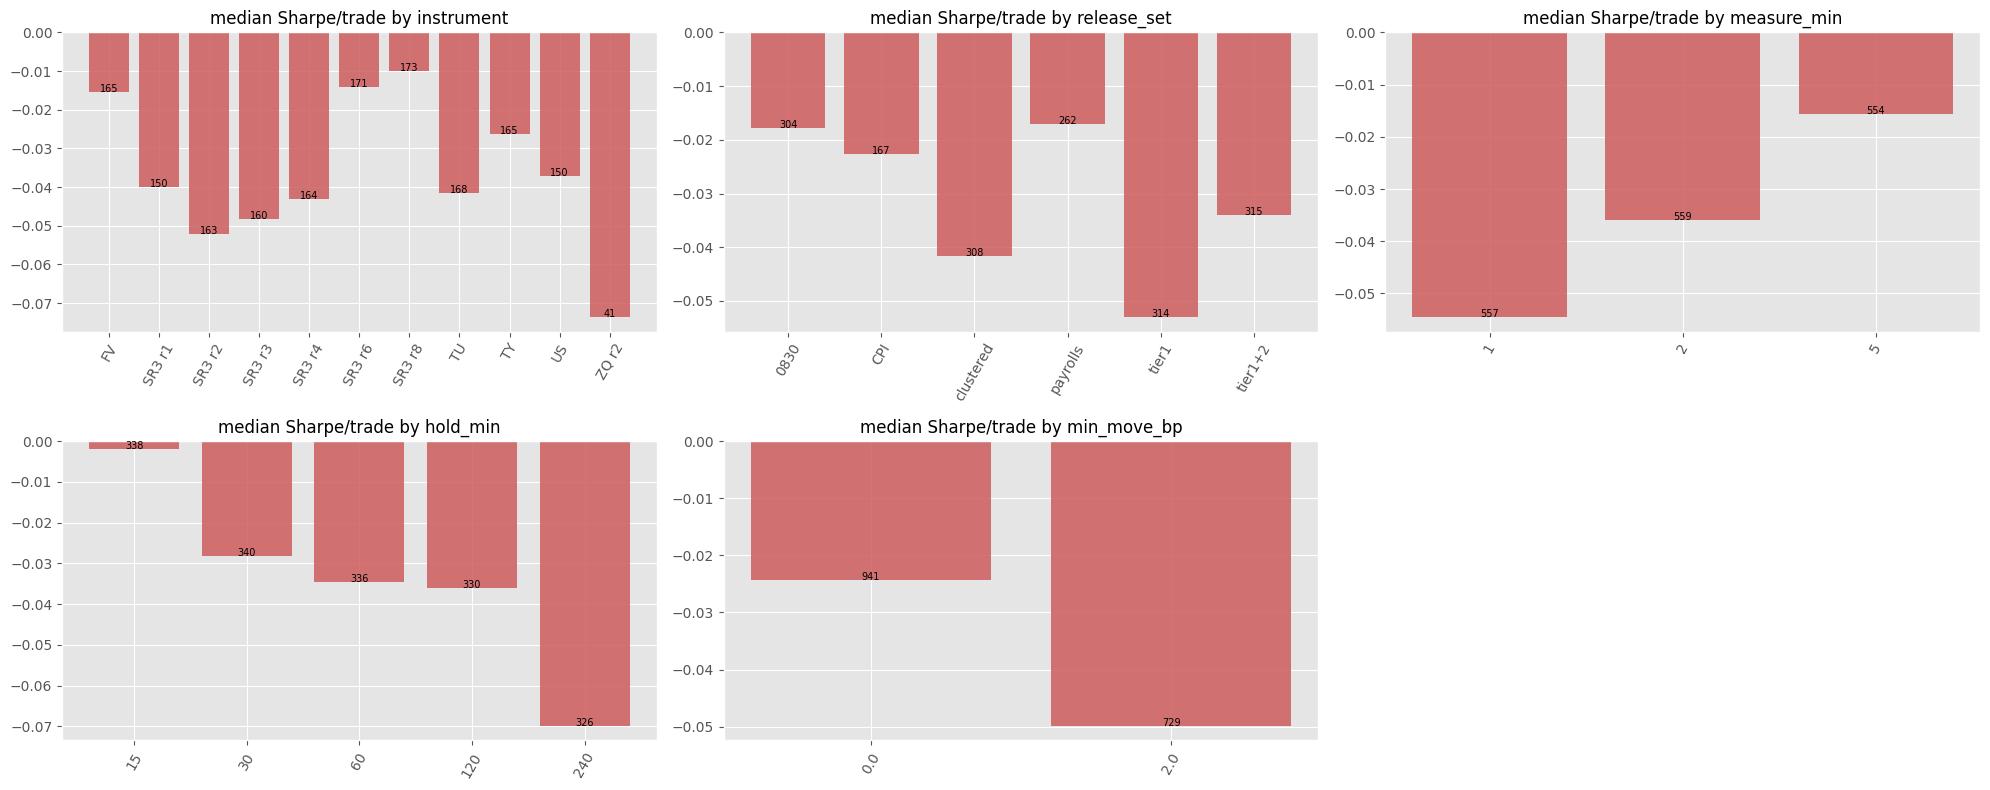

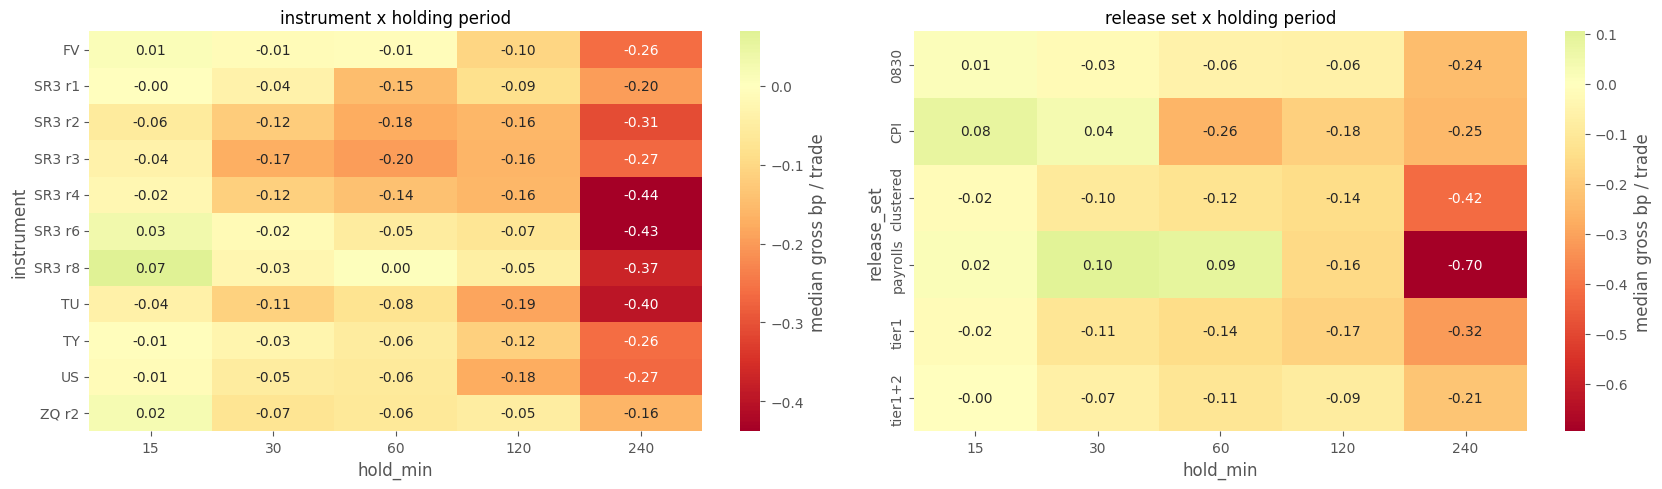

In [6]:
# Which axis actually moves the answer? A marginal that is flat is a knob that
# was never worth turning, and one that is steep is a knob the search exploited.
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
for ax, col in zip(axes.ravel(),
                   ["instrument", "release_set", "measure_min", "hold_min", "min_move_bp"]):
    g = elig.groupby(col).agg(sharpe=("sr_per_trade", "median"), avg_bp=("avg_bp", "median"),
                              n=("sr_per_trade", "size"))
    ax.bar(g.index.astype(str), g.sharpe,
           color=["seagreen" if v > 0 else "indianred" for v in g.sharpe], alpha=.85)
    for i, (nm, r) in enumerate(g.iterrows()):
        ax.text(i, r.sharpe, f"{int(r.n)}", ha="center", fontsize=7)
    ax.axhline(0, color="k", lw=.7); ax.set_title(f"median Sharpe/trade by {col}")
    ax.tick_params(axis="x", rotation=60)
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

piv = elig.pivot_table(index="instrument", columns="hold_min", values="avg_bp", aggfunc="median")
piv2 = elig.pivot_table(index="release_set", columns="hold_min", values="avg_bp", aggfunc="median")
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[0],
            cbar_kws={"label": "median gross bp / trade"})
axes[0].set_title("instrument x holding period")
sns.heatmap(piv2, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1],
            cbar_kws={"label": "median gross bp / trade"})
axes[1].set_title("release set x holding period")
plt.tight_layout(); plt.show()

## 4. What the search cost

The Deflated Sharpe compares each configuration against `E[max Sharpe]` under the null that all of
them have zero edge, with the null's variance taken from the spread of Sharpes the grid actually
produced. It is generous here — these configurations overlap heavily in the same release minutes,
so they are nothing like the independent trials the formula assumes, and the true hurdle is higher
than the one printed below.

A configuration is called **ALIVE** only if it clears three bars at once: DSR above 0.95, at least
50 trades, and a gross edge above the 0.5 bp tick. The last is not a statistical test — it is the
difference between a result and a bill.

NOTE: per-trade series available for 2,097 of 2,160 configurations. The rest either booked no trades or were resumed from CSV.
The deflation below therefore uses a SMALLER trial count than the grid actually
ran, so it is too generous. Re-run with a fresh grid_results.csv for the honest number.
1,670 configurations scored   selection hurdle sr* = 0.2170 per trade   (variance of observed Sharpes 0.00408)


,trades,sr_per_trade,avg_bp,total_bp,dsr
config,,,,,
SR3 r1|CPI|m5|h15|mv0,67,0.2307,0.2052,13.7500,0.5451
ZQ r2|tier1+2|m5|h15|mv0,114,0.2256,0.1009,11.5000,0.5405
SR3 r2|payrolls|m5|h15|mv2,50,0.1831,0.2800,14.0000,0.4075
SR3 r8|payrolls|m5|h15|mv2,54,0.1797,0.4259,23.0000,0.3957
SR3 r8|payrolls|m1|h30|mv2,62,0.1693,0.6290,39.0000,0.3480
SR3 r8|payrolls|m5|h60|mv2,54,0.1594,0.6944,37.5000,0.3435
ZQ r2|tier1|m5|h15|mv0,87,0.1675,0.0690,6.0000,0.3232
SR3 r8|payrolls|m1|h60|mv2,62,0.1585,0.7258,45.0000,0.3207
SR3 r8|payrolls|m5|h30|mv2,54,0.1468,0.4722,25.5000,0.3029



ALIVE (DSR > 0.95, >= 50 trades, gross edge > one 0.5bp tick): 0 of 1670
  (0 clear the statistical bar but not the cost bar)


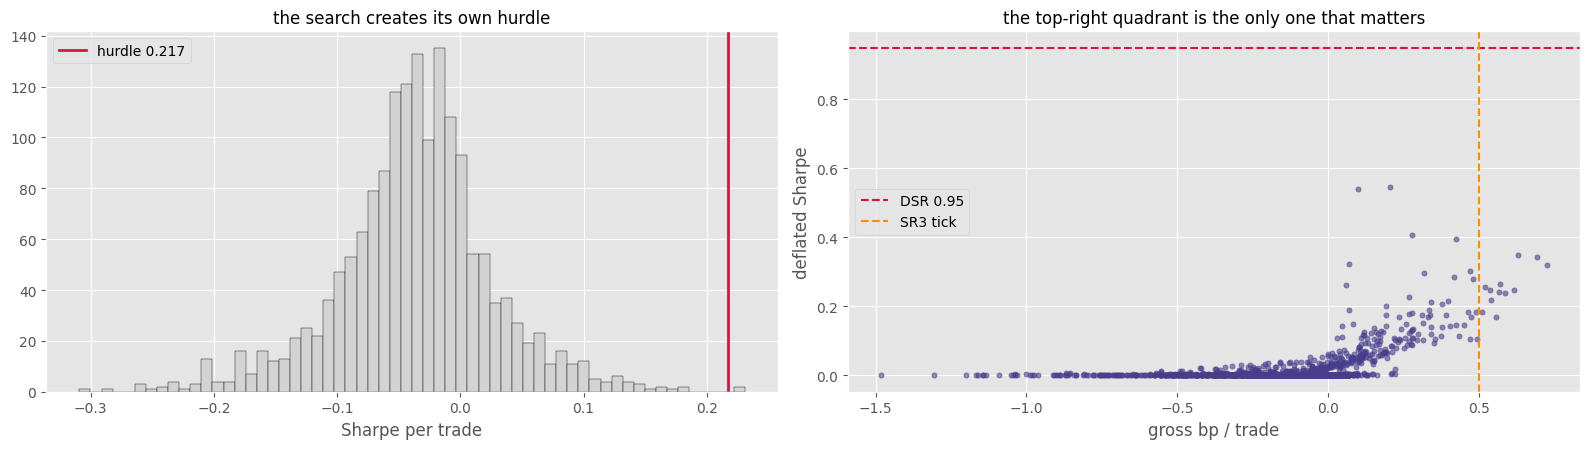

In [7]:
# PNL holds only the configurations scored in THIS kernel. On a resumed run the
# summary CSV is complete but the per-trade series are not, and a DSR computed
# from a partial set would silently use a smaller trial count -- which flatters
# the winner. Say so rather than quietly deflating by the wrong number.
if len(PNL) < len(RESULTS):
    print(f"NOTE: per-trade series available for {len(PNL):,} of {len(RESULTS):,} "
          f"configurations. The rest either booked no trades or were resumed from CSV.")
    print("The deflation below therefore uses a SMALLER trial count than the grid actually")
    print("ran, so it is too generous. Re-run with a fresh grid_results.csv for the honest number.")

sr_pt = {nm: (v.mean() / v.std(ddof=1)) if v.std(ddof=1) > 0 else 0.0
         for nm, v in PNL.items() if len(v) >= MIN_TRADES}
n_trials = max(len(sr_pt), 1)
var_sr = float(np.var(list(sr_pt.values()), ddof=1)) if len(sr_pt) > 1 else 0.0
sr_star = G.expected_max_sharpe(var_sr, n_trials)
print(f"{n_trials:,} configurations scored   selection hurdle sr* = {sr_star:.4f} per trade   "
      f"(variance of observed Sharpes {var_sr:.5f})")

dsr = pd.DataFrame([
    {"config": nm, "trades": len(v), "sr_per_trade": sr_pt[nm], "avg_bp": v.mean(),
     "total_bp": v.sum(), "dsr": G.deflated_sharpe(v, sr_star)}
    for nm, v in PNL.items() if nm in sr_pt
]).sort_values("dsr", ascending=False).set_index("config")
display(dsr.head(20).round(4))

alive = dsr[(dsr.dsr > 0.95) & (dsr.trades >= MIN_TRADES) & (dsr.avg_bp > 0.5)]
print(f"\nALIVE (DSR > 0.95, >= {MIN_TRADES} trades, gross edge > one 0.5bp tick): "
      f"{len(alive)} of {len(dsr)}")
if len(alive):
    display(alive.round(4))
else:
    passes_dsr = int(((dsr.dsr > 0.95) & (dsr.trades >= MIN_TRADES)).sum())
    print(f"  ({passes_dsr} clear the statistical bar but not the cost bar)")

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
axes[0].hist(list(sr_pt.values()), bins=60, color="lightgrey", edgecolor="k", lw=.3)
axes[0].axvline(sr_star, color="crimson", lw=2, label=f"hurdle {sr_star:.3f}")
axes[0].set_xlabel("Sharpe per trade"); axes[0].legend()
axes[0].set_title("the search creates its own hurdle")
axes[1].scatter(dsr.avg_bp, dsr.dsr, s=14, alpha=.6, color="darkslateblue")
axes[1].axhline(0.95, color="crimson", ls="--", lw=1.5, label="DSR 0.95")
axes[1].axvline(0.5, color="darkorange", ls="--", lw=1.5, label="SR3 tick")
axes[1].set_xlabel("gross bp / trade"); axes[1].set_ylabel("deflated Sharpe"); axes[1].legend()
axes[1].set_title("the top-right quadrant is the only one that matters")
plt.tight_layout(); plt.show()

### 4.1 Two better instruments than the Deflated Sharpe

The DSR above prices the search by its **size**. That is the wrong axis for this grid: 2,000
configurations that differ by a holding period are not 2,000 experiments, and a penalty driven by
the count alone over-charges a correlated family and under-charges an independent one.

`RVUtils.StatisticalFinance` implements two methods that price it by **what was actually searched**,
following [quantpylib's Statistical Finance notes](https://quantpylib.hangukquant.com/learn/statistical_finance/).

**Romano-Wolf stepdown** (Romano & Wolf, 2005) controls the familywise error rate across every
configuration. It orders the observed statistics, and for the *j*-th it compares against the maximum
of the null over only the hypotheses not yet rejected — so the reference distribution tightens as
the procedure descends. Distribution-free, and strictly more powerful than a Bonferroni or than
comparing every rank against the global maximum.

**The Rademacher Anti-Serum** (Paleologo) returns a lower bound on the true Sharpe holding with 95%
probability in finite samples:

    θ ≥ θ̂ − 2R̂ − 3·sqrt(2·ln(2/δ)/T) − sqrt(2·ln(2N/δ)/T)

`R̂` is the empirical Rademacher complexity — how much of a *random* pattern of +1/−1 the best
member of this family can fit. It is measured on the grid itself, so a family of near-duplicates is
charged nearly nothing for its size while a genuinely diverse family pays. A configuration whose
bound clears zero is **Rademacher positive**.

The null for both is a **shared** Rademacher sign flip across configurations, aligned on the release
timestamp. Shared matters: configurations that traded the same prints the same way flip together, so
the family maximum keeps the grid's real correlation. Flipping each column independently would
pretend the grid was thousands of independent experiments and inflate the null's maximum, which
makes every family p-value far too forgiving. A row *permutation* would be useless here — a column's
mean and standard deviation are both invariant to reordering its rows, so the Sharpe would not move
at all.

family: 1,670 configurations, up to 1,757 trades each
  (490 configurations are excluded: fewer than 50 trades, or resumed from CSV without a per-trade series)



selection-bias adjusted p for the BEST configuration: 1.0000
Romano-Wolf rejects 0 of 1,670 at a 5% familywise level


,strategy,observed,p_raw,p_adjusted,reject
rank,,,,,
1,SR3 r1|CPI|m5|h15|mv0,0.2307,1.0,1.0,False
2,ZQ r2|tier1+2|m5|h15|mv0,0.2256,1.0,1.0,False
3,SR3 r2|payrolls|m5|h15|mv2,0.1831,1.0,1.0,False
4,SR3 r8|payrolls|m5|h15|mv2,0.1797,1.0,1.0,False
5,SR3 r8|payrolls|m1|h30|mv2,0.1693,1.0,1.0,False
6,ZQ r2|tier1|m5|h15|mv0,0.1675,1.0,1.0,False
7,SR3 r8|payrolls|m5|h60|mv2,0.1594,1.0,1.0,False
8,SR3 r8|payrolls|m1|h60|mv2,0.1585,1.0,1.0,False
9,SR3 r8|payrolls|m5|h30|mv2,0.1468,1.0,1.0,False


,value
empirical Sharpe (best),0.05637
R_hat,0.07844
complexity penalty 2*R_hat,0.15689
sampling error 3*sqrt(2ln(2/d)/T),0.19440
multiple testing sqrt(2ln(2N/d)/T),0.11245
total haircut,0.46374
best RAS lower bound,-0.40737
T,1757.00000
N,1670.00000
delta,0.05000


Rademacher-positive configurations: 0 of 1,670


,configurations passing
deflated Sharpe > 0.95,0
Romano-Wolf reject at 5%,0
Rademacher positive,0
gross edge > one tick,12
ALL FOUR,0



configurations passing ALL FOUR: 0 of 1670


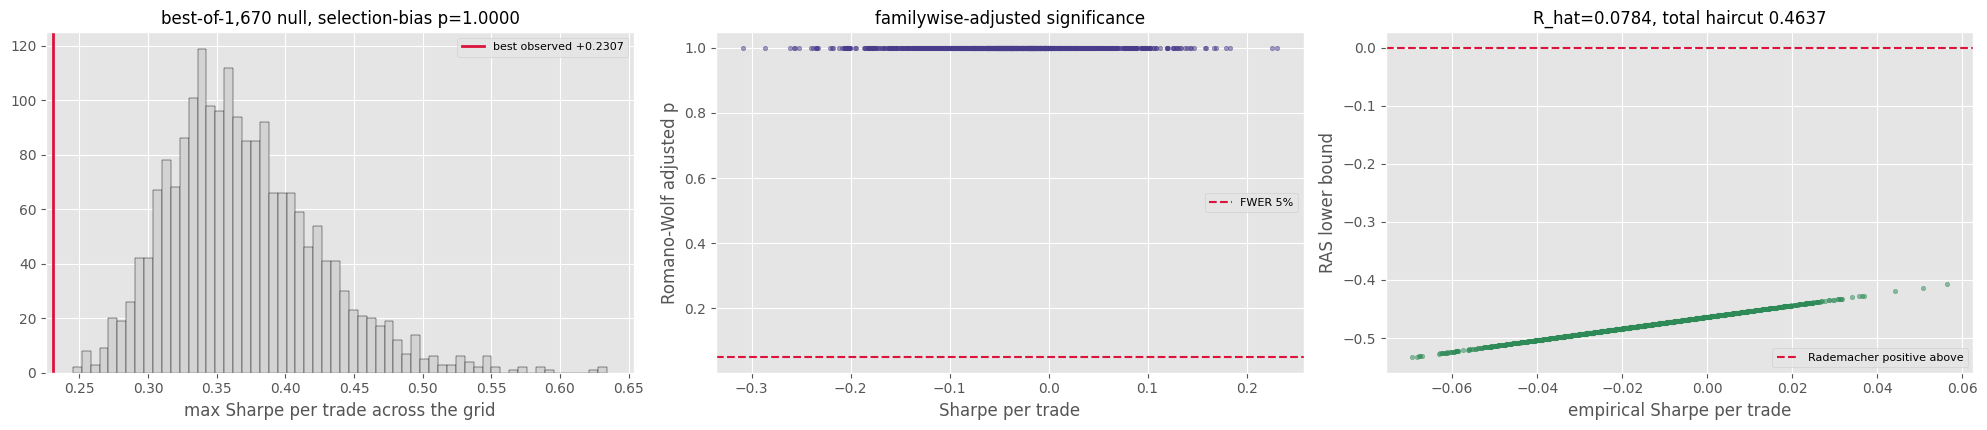

In [8]:
from RVUtils.StatisticalFinance import (
    ras_bound, romano_wolf, selection_bias_pvalue, shared_sign_flip_null,
)

# Align every scored configuration on its release timestamps. Only configs whose
# per-trade series survived this kernel can enter -- a resumed grid has summary
# rows but no series, and silently testing a subset would understate N.
PNL_BOOKS = {nm: pd.DataFrame({"release_ts": np.arange(len(v)), "pnl_bp": v})
             for nm, v in PNL.items() if len(v) >= MIN_TRADES}
X = pd.DataFrame({nm: pd.Series(v) for nm, v in PNL.items() if len(v) >= MIN_TRADES})
print(f"family: {X.shape[1]:,} configurations, up to {X.shape[0]:,} trades each")
if X.shape[1] < len(RESULTS):
    print(f"  ({len(RESULTS) - X.shape[1]:,} configurations are excluded: fewer than "
          f"{MIN_TRADES} trades, or resumed from CSV without a per-trade series)")

obs_sr = np.array([X[c].dropna().mean() / X[c].dropna().std(ddof=1)
                   if X[c].notna().sum() > 1 else 0.0 for c in X.columns])
NULL = shared_sign_flip_null(X, draws=2000, rng=np.random.default_rng(20260811))

p_best = selection_bias_pvalue(obs_sr, NULL)
RW = romano_wolf(obs_sr, NULL, alpha=0.05, names=list(X.columns))
print(f"\nselection-bias adjusted p for the BEST configuration: {p_best:.4f}")
print(f"Romano-Wolf rejects {RW.n_rejected:,} of {RW.n_strategies:,} at a 5% familywise level")
display(RW.table.head(20).round(4))

RAS = ras_bound(X.fillna(0.0), delta=0.05, draws=2000, rng=np.random.default_rng(4242),
                names=list(X.columns))
display(RAS.terms().to_frame("value").round(5))
pos = RAS.table()[RAS.table()["rademacher_positive"]]
print(f"Rademacher-positive configurations: {len(pos):,} of {RAS.N:,}")
if len(pos):
    display(pos.round(5).head(15))

# The three verdicts side by side. They should agree; where they do not, the one
# that assumes least about the return distribution is the one to believe.
survivors = pd.DataFrame({
    "deflated Sharpe > 0.95": dsr.reindex(X.columns)["dsr"] > 0.95,
    "Romano-Wolf reject at 5%": RW.table.set_index("strategy").reindex(X.columns)["reject"],
    "Rademacher positive": pd.Series(RAS.bound > 0, index=X.columns),
    "gross edge > one tick": pd.Series(
        [float(X[c].dropna().mean()) > 0.5 for c in X.columns], index=X.columns),
})
survivors["ALL FOUR"] = survivors.all(axis=1)
display(survivors.sum().to_frame("configurations passing"))
print(f"\nconfigurations passing ALL FOUR: {int(survivors['ALL FOUR'].sum())} of {len(survivors)}")

fig, axes = plt.subplots(1, 3, figsize=(20, 4.4))
axes[0].hist(np.nanmax(NULL, axis=1), bins=60, color="lightgrey", edgecolor="k", lw=.3)
axes[0].axvline(obs_sr.max(), color="crimson", lw=2, label=f"best observed {obs_sr.max():+.4f}")
axes[0].set_xlabel("max Sharpe per trade across the grid"); axes[0].legend(fontsize=8)
axes[0].set_title(f"best-of-{X.shape[1]:,} null, selection-bias p={p_best:.4f}")
axes[1].scatter(RW.table["observed"], RW.table["p_adjusted"], s=10, alpha=.5,
                color="darkslateblue")
axes[1].axhline(0.05, color="crimson", ls="--", lw=1.5, label="FWER 5%")
axes[1].set_xlabel("Sharpe per trade"); axes[1].set_ylabel("Romano-Wolf adjusted p")
axes[1].legend(fontsize=8); axes[1].set_title("familywise-adjusted significance")
t = RAS.table()
axes[2].scatter(t["sharpe"], t["ras_lower_bound"], s=10, alpha=.5, color="seagreen")
axes[2].axhline(0, color="crimson", ls="--", lw=1.5, label="Rademacher positive above")
axes[2].set_xlabel("empirical Sharpe per trade"); axes[2].set_ylabel("RAS lower bound")
axes[2].legend(fontsize=8)
axes[2].set_title(f"R_hat={RAS.rademacher:.4f}, total haircut {RAS.haircut:.4f}")
plt.tight_layout(); plt.show()

## 5. The same grid on a day with no release

Every timestamp shifted forward one **business** day. Same instruments, same clock, same windows,
same causal gate — no release.

Business days, not calendar days: a calendar +1 sends every Friday release to a Saturday, where the
gate deletes it, and payrolls is a Friday release. The composition table below has to show the
placebo keeping essentially every weekday, or the two distributions differ because the sample
changed rather than because the news went away.

This is the strongest single test in either notebook, and it is stronger as a **distribution** than
as a single book. If the real grid's Sharpes are drawn from the same distribution as the placebo
grid's, then the release contributes nothing and every number above is a description of what
happens at 08:30 in the Treasury market on any given morning.

,real,placebo,kept %
release weekday,,,
Wed,794,622,78.3
Thu,725,487,67.2
Fri,585,537,91.8
Tue,518,386,74.5
Mon,222,166,74.8
Sun,18,17,94.4
Sat,8,8,100.0


real 2,870 release minutes -> placebo 2,223



placebo:   0%|          | 0/2160 [00:00<?, ?it/s]

placebo: 2,160 configs in 495s -> C:\Users\chris\clee\ARBS-eco\notebooks\backtests\econ_release_fade\_cache\grid_results_placebo.csv


,configs,median sharpe/trade,best sharpe/trade,median bp/trade,best bp/trade,% positive,% clearing a tick
grid,,,,,,,
REAL releases,1670,-0.0355,0.2307,-0.0956,0.7258,0.2263,0.0072
wrong day (+1),663,0.0504,0.2994,0.0918,1.1584,0.8145,0.0633



real against placebo, bp per trade: Mann-Whitney p = 3.154e-154
real against placebo, Sharpe:        KS p = 3.962e-160

The grids differ. Real releases pay -0.1874 bp/trade more at the median.
That gap, not the leaderboard's best cell, is the size of the effect.


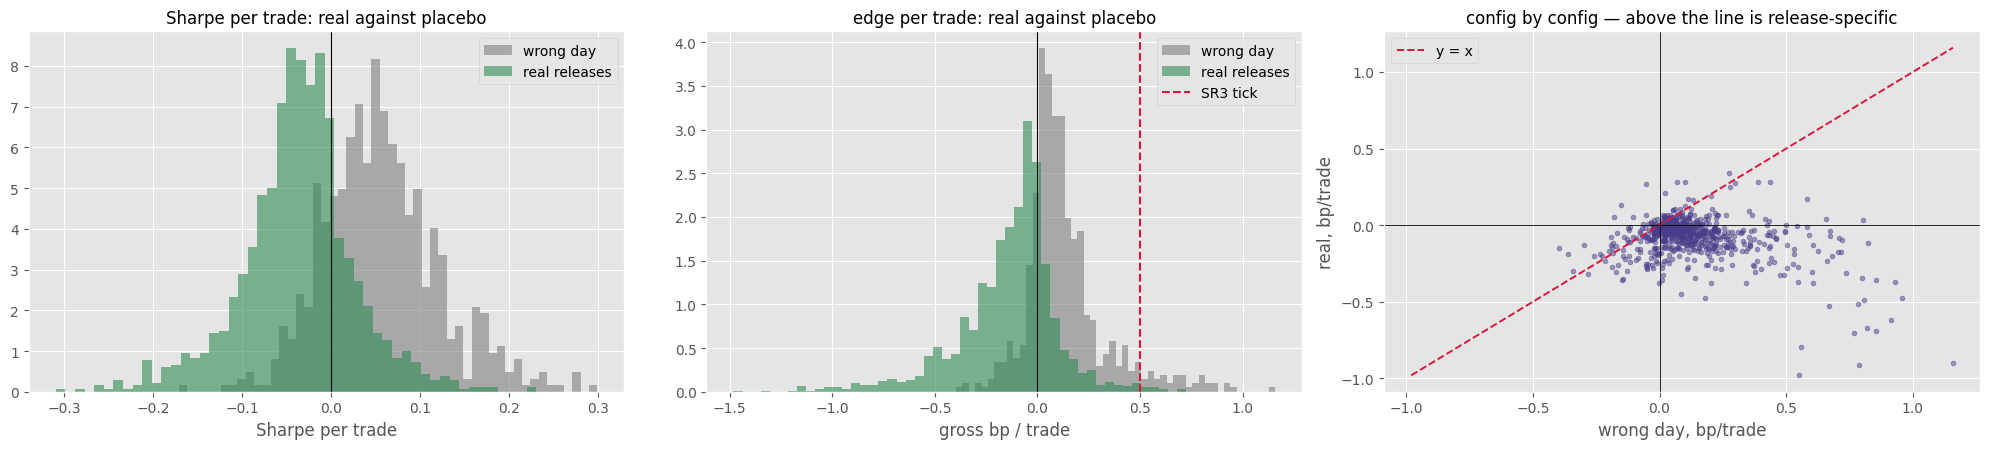

In [9]:
RAW_PLACEBO = C.placebo_shift(RAW, days=1)   # business day; real release minutes removed
display(C.placebo_composition(RAW, RAW_PLACEBO).rename_axis("release weekday"))
print(f"real {len(RAW):,} release minutes -> placebo {len(RAW_PLACEBO):,}\n")

PLACEBO, PNL_P = run_grid(build_grid(), RAW_PLACEBO, "placebo", PLACEBO_CSV)

pe = PLACEBO[PLACEBO.trades >= MIN_TRADES]
rows = []
for nm, d in (("REAL releases", elig), ("wrong day (+1)", pe)):
    rows.append({"grid": nm, "configs": len(d),
                 "median sharpe/trade": d.sr_per_trade.median(),
                 "best sharpe/trade": d.sr_per_trade.max(),
                 "median bp/trade": d.avg_bp.median(), "best bp/trade": d.avg_bp.max(),
                 "% positive": float((d.avg_bp > 0).mean()),
                 "% clearing a tick": float((d.avg_bp > 0.5).mean())})
display(pd.DataFrame(rows).set_index("grid").round(4))

from scipy.stats import mannwhitneyu, ks_2samp
if len(pe) and len(elig):
    u = mannwhitneyu(elig.avg_bp.dropna(), pe.avg_bp.dropna(), alternative="two-sided")
    k = ks_2samp(elig.sr_per_trade.dropna(), pe.sr_per_trade.dropna())
    print(f"\nreal against placebo, bp per trade: Mann-Whitney p = {u.pvalue:.4g}")
    print(f"real against placebo, Sharpe:        KS p = {k.pvalue:.4g}")
    if u.pvalue > 0.05:
        print("\nThe two grids are indistinguishable. Whatever the leaderboard found, a day with")
        print("no release finds the same thing -- this is the clock, not the release.")
    else:
        better = elig.avg_bp.median() - pe.avg_bp.median()
        print(f"\nThe grids differ. Real releases pay {better:+.4f} bp/trade more at the median.")
        print("That gap, not the leaderboard's best cell, is the size of the effect.")

fig, axes = plt.subplots(1, 3, figsize=(20, 4.6))
axes[0].hist(pe.sr_per_trade, bins=50, alpha=.6, label="wrong day", color="grey", density=True)
axes[0].hist(elig.sr_per_trade, bins=50, alpha=.6, label="real releases", color="seagreen",
             density=True)
axes[0].axvline(0, color="k", lw=.8); axes[0].legend(); axes[0].set_xlabel("Sharpe per trade")
axes[0].set_title("Sharpe per trade: real against placebo")
axes[1].hist(pe.avg_bp, bins=50, alpha=.6, label="wrong day", color="grey", density=True)
axes[1].hist(elig.avg_bp, bins=50, alpha=.6, label="real releases", color="seagreen", density=True)
axes[1].axvline(0, color="k", lw=.8); axes[1].axvline(0.5, color="crimson", ls="--", lw=1.5,
                                                      label="SR3 tick")
axes[1].legend(); axes[1].set_xlabel("gross bp / trade")
axes[1].set_title("edge per trade: real against placebo")

m = elig[["config", "avg_bp"]].merge(pe[["config", "avg_bp"]], on="config",
                                     suffixes=("_real", "_placebo"))
if len(m):
    axes[2].scatter(m.avg_bp_placebo, m.avg_bp_real, s=12, alpha=.5, color="darkslateblue")
    lim = [min(m.avg_bp_placebo.min(), m.avg_bp_real.min()),
           max(m.avg_bp_placebo.max(), m.avg_bp_real.max())]
    axes[2].plot(lim, lim, color="crimson", lw=1.4, ls="--", label="y = x")
    axes[2].axhline(0, color="k", lw=.6); axes[2].axvline(0, color="k", lw=.6)
    axes[2].set_xlabel("wrong day, bp/trade"); axes[2].set_ylabel("real, bp/trade"); axes[2].legend()
    axes[2].set_title("config by config — above the line is release-specific")
plt.tight_layout(); plt.show()

## 6. The same grid, faded the other way

`momentum` is the identical set of trades with the sign reversed. Gross of cost the two grids must
be near mirror images of each other, and a scatter of one against the other must sit on the line
`y = -x`. If it does not, the P&L is not coming from the direction of the initial move — it is
coming from the sizing, the gate, or the marking, and none of those is the strategy.

This is a check on the machinery rather than on the idea. Because the closed form negates exactly —
same events, same prices, flipped side — it verifies one function, `apply_signal`'s flip, and a
sample of the grid proves that as well as the whole grid would. **Every fifth configuration is run**,
and the count is printed so the sample is not mistaken for the full product. It is also the check
that catches a sign error, which is the single most common way a fade backtest becomes a momentum
backtest without anyone noticing.

momentum grid: running 432 of 2,160 configurations (every 5th) -- the closed form negates exactly, so this checks the
sign flip rather than searching a second config space.


momentum:   0%|          | 0/432 [00:00<?, ?it/s]

momentum: 432 configs in 171s -> C:\Users\chris\clee\ARBS-eco\notebooks\backtests\econ_release_fade\_cache\grid_results_momentum.csv
338 configurations present in both grids
fade + momentum, per trade: mean +0.000000 bp, max |0.000000| bp
(both books pay the same zero cost here, so the pair must sum to zero within the
 rounding of the tick lattice -- a systematic offset would be a marking bug)


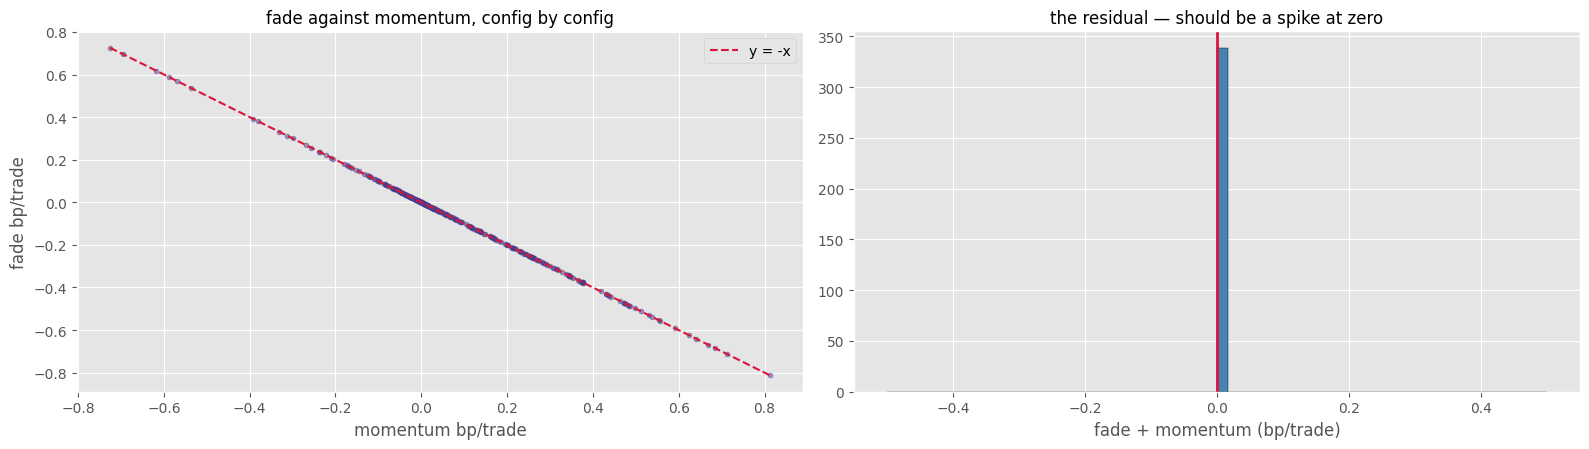

In [10]:
MOM_SAMPLE = build_grid("momentum")[::5]
print(f"momentum grid: running {len(MOM_SAMPLE):,} of {len(build_grid('momentum')):,} "
      f"configurations (every 5th) -- the closed form negates exactly, so this checks the")
print("sign flip rather than searching a second config space.")
MOM, PNL_M = run_grid(MOM_SAMPLE, RAW, "momentum",
                      G.CACHE / "grid_results_momentum.csv")
me = MOM[MOM.trades >= MIN_TRADES]

j = elig[["config", "avg_bp", "trades"]].merge(
    me[["config", "avg_bp"]], on="config", suffixes=("_fade", "_mom"))
j["sum"] = j.avg_bp_fade + j.avg_bp_mom
print(f"{len(j):,} configurations present in both grids")
print(f"fade + momentum, per trade: mean {j['sum'].mean():+.6f} bp, "
      f"max |{j['sum'].abs().max():.6f}| bp")
print("(both books pay the same zero cost here, so the pair must sum to zero within the")
print(" rounding of the tick lattice -- a systematic offset would be a marking bug)")

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
axes[0].scatter(j.avg_bp_mom, j.avg_bp_fade, s=12, alpha=.5, color="darkslateblue")
lim = [j.avg_bp_mom.min(), j.avg_bp_mom.max()]
axes[0].plot(lim, [-v for v in lim], color="crimson", lw=1.5, ls="--", label="y = -x")
axes[0].set_xlabel("momentum bp/trade"); axes[0].set_ylabel("fade bp/trade"); axes[0].legend()
axes[0].set_title("fade against momentum, config by config")
axes[1].hist(j["sum"], bins=60, color="steelblue", edgecolor="k", lw=.3)
axes[1].axvline(0, color="crimson", lw=2)
axes[1].set_xlabel("fade + momentum (bp/trade)")
axes[1].set_title("the residual — should be a spike at zero")
plt.tight_layout(); plt.show()

## 7. The whole grid, net of a real cost

Every configuration re-scored at a round trip a desk would actually pay. This strategy trades once
per release and holds for minutes, so cost is not a haircut on the answer — at this frequency it
*is* the answer.

The count that matters is the last column: how many of a thousand configurations are still standing
at each cost. If that number goes to zero by half a tick, the search found nothing tradeable no
matter how the leaderboard looked at zero.

,median bp/trade,best bp/trade,median sharpe,best sharpe,configs profitable,configs w/ sharpe > 1
cost_bp_rt,,,,,,
0.00,-0.0956,0.7258,-0.2319,1.8114,378,2
0.10,-0.1956,0.6258,-0.4898,0.4069,152,0
0.25,-0.3456,0.4758,-0.8094,0.2970,61,0
0.50,-0.5956,0.2258,-1.3055,0.1409,12,0
0.75,-0.8456,-0.0242,-1.8049,-0.0151,0,0
1.00,-1.0956,-0.2742,-2.2957,-0.1711,0,0


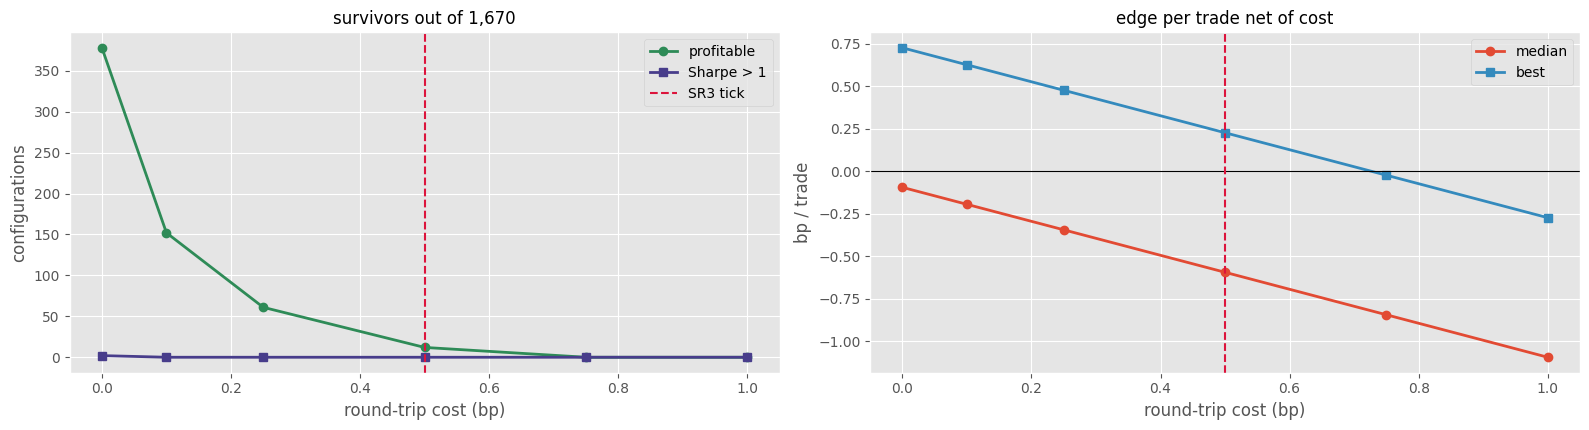

In [11]:
rows = []
for c in [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]:
    net_avg = elig.avg_bp - c
    # Sharpe scales with the mean, so the net Sharpe is the gross one shifted by
    # the cost in units of the per-trade standard deviation.
    sd = elig.avg_bp / elig.sr_per_trade.replace(0, np.nan)
    net_sr = (elig.avg_bp - c) / sd * np.sqrt(elig.trades_per_year)
    rows.append({"cost_bp_rt": c, "median bp/trade": net_avg.median(),
                 "best bp/trade": net_avg.max(), "median sharpe": net_sr.median(),
                 "best sharpe": net_sr.max(),
                 "configs profitable": int((net_avg > 0).sum()),
                 "configs w/ sharpe > 1": int((net_sr > 1).sum())})
cost_tbl = pd.DataFrame(rows).set_index("cost_bp_rt")
display(cost_tbl.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.4))
axes[0].plot(cost_tbl.index, cost_tbl["configs profitable"], marker="o", lw=2,
             color="seagreen", label="profitable")
axes[0].plot(cost_tbl.index, cost_tbl["configs w/ sharpe > 1"], marker="s", lw=2,
             color="darkslateblue", label="Sharpe > 1")
axes[0].axvline(0.5, color="crimson", ls="--", lw=1.5, label="SR3 tick")
axes[0].set_xlabel("round-trip cost (bp)"); axes[0].set_ylabel("configurations")
axes[0].set_title(f"survivors out of {len(elig):,}"); axes[0].legend()
axes[1].plot(cost_tbl.index, cost_tbl["median bp/trade"], marker="o", lw=2, label="median")
axes[1].plot(cost_tbl.index, cost_tbl["best bp/trade"], marker="s", lw=2, label="best")
axes[1].axhline(0, color="k", lw=.8); axes[1].axvline(0.5, color="crimson", ls="--", lw=1.5)
axes[1].set_xlabel("round-trip cost (bp)"); axes[1].set_ylabel("bp / trade"); axes[1].legend()
axes[1].set_title("edge per trade net of cost")
plt.tight_layout(); plt.show()

## 8. The winner, run properly

Whatever the grid picked, it is picked on the closed form. Here it is re-run through the real
engine and given the full robustness treatment — because a grid winner is a hypothesis, and the
one thing that is certain about it is that it was selected for looking good.

grid winner: {
 "name": "SR3 r1|CPI|m5|h15|mv0",
 "instrument": {
  "family": "stir",
  "root": "USD_STIR",
  "rank": 1
 },
 "events": {
  "currencies": [
   "USD"
  ],
  "impacts": [
   "high",
   "medium"
  ],
  "titles_include": [
   "\\bCPI\\b"
  ],
  "titles_exclude": null,
  "require_actual": true,
  "include_cb_decisions": false,
  "start": null,
  "end": null,
  "weekdays": null,
  "surprise": "any",
  "min_events_in_minute": 1,
  "release_times_ny": null
 },
 "timing": {
  "measure_start_min": 0,
  "measure_end_min": 5,
  "entry_offset_min": 6,
  "exit_offset_min": 15,
  "max_staleness_min": 5,
  "same_day_exit": true
 },
 "signal": {
  "direction": "fade",
  "source": "move",
  "min_move_bp": 0.0,
  "max_move_bp": null
 }
}


SR3 r1|CPI|m5|h15|mv0:   0%|          | 0/134 [00:00<?, ?step/s]

SR3 r1|CPI|m5|h15|mv0:  46%|████▋     | 62/134 [00:00<00:00, 618.02step/s]

SR3 r1|CPI|m5|h15|mv0:  93%|█████████▎| 124/134 [00:00<00:00, 616.87step/s]

SR3 r1|CPI|m5|h15|mv0: 100%|██████████| 134/134 [00:00<00:00, 624.06step/s]

,trades,total_bp,avg_bp,std_bp,hit_rate,sharpe,sr_per_trade,t_stat,max_dd_bp,trades_per_year,span_days,first,last
engine run,67,13.75,0.205224,0.889677,0.492537,0.68925,0.230672,1.888134,-5.5,8.928173,2740.958333,2019-01-11 13:30:00+00:00,2026-07-14 12:30:00+00:00


sign-flip permutation p = 0.0630   bootstrap 95% CI on the mean [-0.0075, +0.4142] bp
break-even round trip: +0.2052 bp (does NOT clear one SR3 tick)


same config on the wrong day: 11 trades, +0.0455 bp/trade


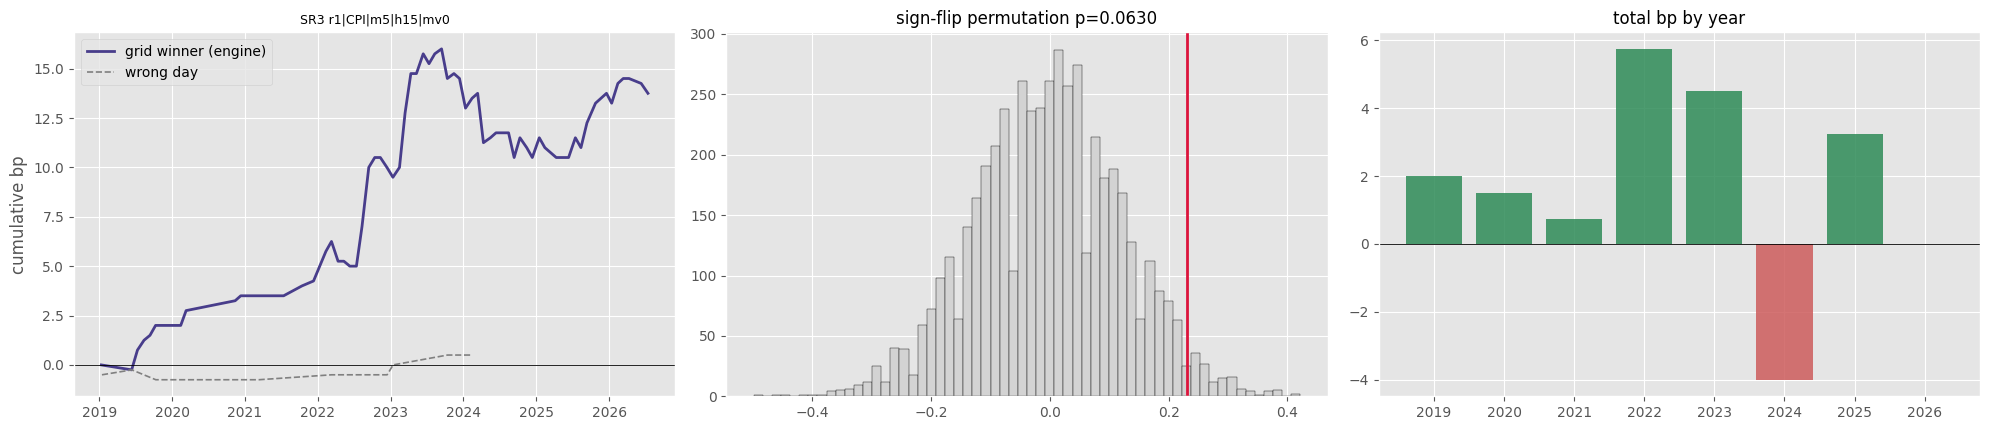

In [12]:
# The winner is chosen on sr_per_trade, the same statistic the deflated Sharpe,
# Romano-Wolf and RAS all scored -- selecting on the annualised figure would
# crown a configuration none of those tests ever ranked.
best_name = elig.sort_values("sr_per_trade", ascending=False).iloc[0]["config"]
best_cfg = next(c for c in GRID if c["name"] == best_name)
print("grid winner:", json.dumps({k: v for k, v in best_cfg.items()
                                  if k in ("name", "instrument", "events", "timing", "signal")},
                                 indent=1, default=str))

BEST = C.run_config(best_cfg, RAW, engine=True, show_progress=True)
B = BEST.closed
display(pd.Series(G.summarize(B)).to_frame("engine run").T.round(4))

perm = G.sign_flip_permutation(B, n_perm=5000)
lo, hi = G.bootstrap_ci(B.pnl_bp.to_numpy(float))
print(f"sign-flip permutation p = {perm['p_value']:.4f}   "
      f"bootstrap 95% CI on the mean [{lo:+.4f}, {hi:+.4f}] bp")
print(f"break-even round trip: {B.pnl_bp_gross.mean():+.4f} bp "
      f"({'clears' if B.pnl_bp_gross.mean() > 0.5 else 'does NOT clear'} one SR3 tick)")

pl = C.run_config(best_cfg, C.placebo_shift(RAW, days=1), engine=False)
print(f"same config on the wrong day: {pl.stats.get('trades', 0)} trades, "
      f"{pl.stats.get('avg_bp', float('nan')):+.4f} bp/trade")

fig, axes = plt.subplots(1, 3, figsize=(20, 4.4))
axes[0].plot(B.release_ts.values, B.pnl_bp.cumsum().values, lw=2, color="darkslateblue",
             label="grid winner (engine)")
if not pl.closed.empty:
    axes[0].plot(pl.closed.release_ts.values, pl.closed.pnl_bp.cumsum().values, lw=1.2,
                 ls="--", color="grey", label="wrong day")
axes[0].axhline(0, color="k", lw=.6); axes[0].legend(); axes[0].set_ylabel("cumulative bp")
axes[0].set_title(best_name, fontsize=9)
axes[1].hist(perm["perm"], bins=60, color="lightgrey", edgecolor="k", lw=.3)
axes[1].axvline(perm["realized_sharpe"], color="crimson", lw=2)
axes[1].set_title(f"sign-flip permutation p={perm['p_value']:.4f}")
y = B.groupby("year").pnl_bp.sum()
axes[2].bar(y.index.astype(str), y.values,
            color=["seagreen" if v > 0 else "indianred" for v in y.values], alpha=.85)
axes[2].axhline(0, color="k", lw=.6); axes[2].set_title("total bp by year")
plt.tight_layout(); plt.show()

## 9. Reading this notebook

**The leaderboard is the least informative table here.** With a thousand configurations its top row
is an order statistic. §4 tells you what that order statistic is worth, and §5 tells you whether the
whole distribution it came from is any different from noise.

**The placebo grid is the result.** Not the winner — the *gap* between the two distributions. If
real releases and wrong days produce the same spread of Sharpes, there is nothing here, and no
amount of further slicing will change that. If they differ, the size of the difference at the
median is the honest estimate of the effect, and it will be much smaller than the best cell.

**The tick line is not decoration.** A configuration trading a hundred times a year at 0.3 bp gross
is losing 20 bp a year against a 0.5 bp round trip. Half the panels here draw that line because it
is the constraint the whole idea has to beat, and it does not care how significant the t-statistic
is.

**Reruns are resumable and the CSVs are the record.** `grid_results.csv`, `grid_results_placebo.csv`
and `grid_results_momentum.csv` hold every configuration scored, so a claim made from this notebook
can be checked against the row that produced it.